In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.append(r"C:\Users\super\DAG")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from MEC import is_in_markov_equiv_class
from SCM_data import generate_scm_from_BN 
from numpy.linalg import inv
from scipy.linalg import sqrtm

# Import all three epoch algorithms
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0_epoch, f as f_A
from coordinate_descent.cd_B import dag_coordinate_descent_B_epoch, weight_to_adjacency as wa_B, f_B
from coordinate_descent.cd_B_Omega import dag_coordinate_descent_BOmega_epoch, ell

print(f"Working directory: {os.getcwd()}")

c:\Users\super\DAG\experiments
Working directory: c:\Users\super\DAG\experiments


In [2]:
# Define Experiment 5: d=4, A→C, A→D, B→C, B→D
experiment = {
    "name": "d=4, A→C, A→D, B→C, B→D",
    "B_true": np.array([
        [0, 0, 2, 3],
        [0, 0, 3, 4],
        [0, 0, 0, 0],
        [0, 0, 0, 0]
    ]),
    "N": np.array([2, 4, 3, 5]),
}

print(f"=== Experiment: {experiment['name']} ===")
print(f"B_true:\n{experiment['B_true']}")
print(f"N: {experiment['N']}")

=== Experiment: d=4, A→C, A→D, B→C, B→D ===
B_true:
[[0 0 2 3]
 [0 0 3 4]
 [0 0 0 0]
 [0 0 0 0]]
N: [2 4 3 5]


In [3]:
# Generate synthetic data
n_samples = 5000
seed = 41

B_true = experiment["B_true"]
N = experiment["N"]
d = B_true.shape[0]

# Generate data: X = B^T X + noise
data, G_true_gen, _, _ = generate_scm_from_BN(
    B_true.T,  # Transposing as per reference usage
    n_samples=n_samples, 
    N=N, 
    seed=seed
)
n, d = data.shape

# Compute covariance matrix
S = data.T @ data / n

# True scores under two parameterizations
score_true = f_B(B_true, S)
Omega_true = np.diag(N)
A_true = (np.eye(d) - B_true) @ inv(sqrtm(Omega_true))
score_true_A = f_A(A_true, S) / 2

print(f"B_true = \n", B_true)
print(f"A_true = \n", A_true)
print(f"Omega_true = \n", Omega_true)
print(f"Generated {n_samples} samples")
print(f"Sample covariance S shape: {S.shape}")
print(f"Score_true (f_B with B_true): {score_true:.6f}")
print(f"Score_true_A (coordinate0.f with A_true): {score_true_A:.6f}")
print(f"log(det(Omega_true)): {np.log(np.prod(N)):.6f}")

B_true = 
 [[0 0 2 3]
 [0 0 3 4]
 [0 0 0 0]
 [0 0 0 0]]
A_true = 
 [[ 0.70710677  0.         -1.15470052 -1.34164077]
 [ 0.          0.5        -1.73205078 -1.78885436]
 [ 0.          0.          0.57735026  0.        ]
 [ 0.          0.          0.          0.44721359]]
Omega_true = 
 [[2 0 0 0]
 [0 4 0 0]
 [0 0 3 0]
 [0 0 0 5]]
Generated 5000 samples
Sample covariance S shape: (4, 4)
Score_true (f_B with B_true): 4.794817
Score_true_A (coordinate0.f with A_true): 4.397568
log(det(Omega_true)): 4.787492


In [4]:
# Algorithm parameters
n_epochs = 60
threshold = 0.05
lambda_l0 = 0.0
verbose = False

print("="*60)
print("Testing Three Epoch-based Algorithms")
print("="*60)

Testing Three Epoch-based Algorithms


In [5]:
# Algorithm 1: dag_coordinate_descent_l0_epoch
print("\n" + "="*60)
print("Algorithm 1: A_epoch (dag_coordinate_descent_l0_epoch)")
print("="*60)

A_l0, G_l0, score_l0, history_l0 = dag_coordinate_descent_l0_epoch(
    S,
    n_epochs=n_epochs,
    seed=seed,
    threshold=threshold,
    lambda_l0=lambda_l0,
    verbose=verbose
)

# Scale A by 1/2
A_l0_scaled = A_l0 * 0.5
history_l0_scaled = [h * 0.5 for h in history_l0]
score_l0_scaled = score_l0 * 0.5

print(f"\nFinal Results:")
print(f"Score: {score_l0_scaled:.6f}")
print(f"Score_true_B (f_B): {score_true:.6f}")
print(f"Score_true_A (f_A): {score_true_A:.6f}")
print(f"Converged in {len(history_l0)} epochs")
print(f"Estimated A (scaled by 1/2):\n{A_l0_scaled}")
print(f"Estimated G:\n{G_l0}")
print(f"True B:\n{B_true}")

# Check MEC
is_mec_l0 = is_in_markov_equiv_class(G_l0, B_true)
print(f"Is in MEC: {is_mec_l0}")


Algorithm 1: A_epoch (dag_coordinate_descent_l0_epoch)

Final Results:
Score: 4.399035
Score_true_B (f_B): 4.794817
Score_true_A (f_A): 4.397568
Converged in 59 epochs
Estimated A (scaled by 1/2):
[[ 0.35124155  0.00158524 -0.51313816 -0.6792455 ]
 [ 0.          0.25114204 -0.77287181 -0.89355155]
 [ 0.          0.          0.28108584  0.        ]
 [ 0.          0.         -0.0170581   0.22556644]]
Estimated G:
[[0 0 1 1]
 [0 0 1 1]
 [0 0 0 0]
 [0 0 0 0]]
True B:
[[0 0 2 3]
 [0 0 3 4]
 [0 0 0 0]
 [0 0 0 0]]
Is in MEC: True


In [6]:
# Algorithm 2: dag_coordinate_descent_B_epoch
print("\n" + "="*60)
print("Algorithm 2: dag_coordinate_descent_B_epoch")
print("="*60)

B_est, G_B, score_B, history_B, debug_B = dag_coordinate_descent_B_epoch(
    S,
    n_epochs=n_epochs,
    seed=seed,
    threshold=threshold,
    lambda_l0=lambda_l0,
    verbose=verbose
)

print(f"\nFinal Results:")
print(f"Score: {score_B:.6f}")
print(f"Score_true_B (f_B): {score_true:.6f}")
print(f"Score_true_A (f_A): {score_true_A:.6f}")
print(f"Converged in {len(history_B)} epochs")
print(f"Estimated B:\n{B_est}")
print(f"Estimated G:\n{G_B}")
print(f"True B:\n{B_true}")

# Check MEC
is_mec_B = is_in_markov_equiv_class(G_B, B_true)
print(f"Is in MEC: {is_mec_B}")


Algorithm 2: dag_coordinate_descent_B_epoch

Final Results:
Score: 4.794896
Score_true_B (f_B): 4.794817
Score_true_A (f_A): 4.397568
Converged in 60 epochs
Estimated B:
[[ 0.00000000e+00  0.00000000e+00  1.88006335e+00  3.01054274e+00]
 [-3.22697156e-03  0.00000000e+00  2.83347774e+00  3.96038439e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  4.20902453e-02  0.00000000e+00]]
Estimated G:
[[0 0 1 1]
 [0 0 1 1]
 [0 0 0 0]
 [0 0 0 0]]
True B:
[[0 0 2 3]
 [0 0 3 4]
 [0 0 0 0]
 [0 0 0 0]]
Is in MEC: True


In [7]:
# Algorithm 3: dag_coordinate_descent_BOmega_epoch
print("\n" + "="*60)
print("Algorithm 3: dag_coordinate_descent_BOmega_epoch")
print("="*60)

# Initialize Omega
Omega_init = np.eye(d)

B_BOmega, G_BOmega, score_BOmega, history_BOmega, debug_BOmega = dag_coordinate_descent_BOmega_epoch(
    S,
    Omega_init,
    n_epochs=n_epochs,
    seed=seed,
    threshold=threshold,
    lambda_l0=lambda_l0,
    verbose=verbose
)

print(f"\nFinal Results:")
print(f"Score: {score_BOmega:.6f}")
print(f"Score_true_B (f_B): {score_true:.6f}")
print(f"Score_true_A (f_A): {score_true_A:.6f}")
print(f"Converged in {len(history_BOmega)} epochs")
print(f"Estimated B:\n{B_BOmega}")
print(f"Estimated G:\n{G_BOmega}")
print(f"True B:\n{B_true}")

# Check MEC
is_mec_BOmega = is_in_markov_equiv_class(G_BOmega, B_true)
print(f"Is in MEC: {is_mec_BOmega}")


Algorithm 3: dag_coordinate_descent_BOmega_epoch

Final Results:
Score: 4.397509
Score_true_B (f_B): 4.794817
Score_true_A (f_A): 4.397568
Converged in 59 epochs
Estimated B:
[[ 0.         -0.00631214  1.88006335  3.01054274]
 [ 0.          0.          2.82400779  3.96038439]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.04251189  0.        ]]
Estimated G:
[[0 0 1 1]
 [0 0 1 1]
 [0 0 0 0]
 [0 0 0 0]]
True B:
[[0 0 2 3]
 [0 0 3 4]
 [0 0 0 0]
 [0 0 0 0]]
Is in MEC: True


In [8]:
# Summary comparison
print("\n" + "="*60)
print("SUMMARY COMPARISON")
print("="*60)

results = [
    ("A_epoch", len(history_l0), score_l0_scaled, is_mec_l0),
    ("B_epoch", len(history_B), score_B, is_mec_B),
    ("BOmega_epoch", len(history_BOmega), score_BOmega, is_mec_BOmega),
]

print(f"Score_true_B (f_B): {score_true:.6f}")
print(f"Score_true_A (f_A): {score_true_A:.6f}\n")
print(f"{'Algorithm':<20} {'Epochs':<10} {'Final Score':<15} {'In MEC':<10}")
print("-" * 60)
for name, epochs, score, mec in results:
    print(f"{name:<20} {epochs:<10} {score:<15.6f} {str(mec):<10}")

print(f"\nExperiment: {experiment['name']}")
print(f"Sample size: {n_samples}")


SUMMARY COMPARISON
Score_true_B (f_B): 4.794817
Score_true_A (f_A): 4.397568

Algorithm            Epochs     Final Score     In MEC    
------------------------------------------------------------
A_epoch              59         4.399035        True      
B_epoch              60         4.794896        True      
BOmega_epoch         59         4.397509        True      

Experiment: d=4, A→C, A→D, B→C, B→D
Sample size: 5000


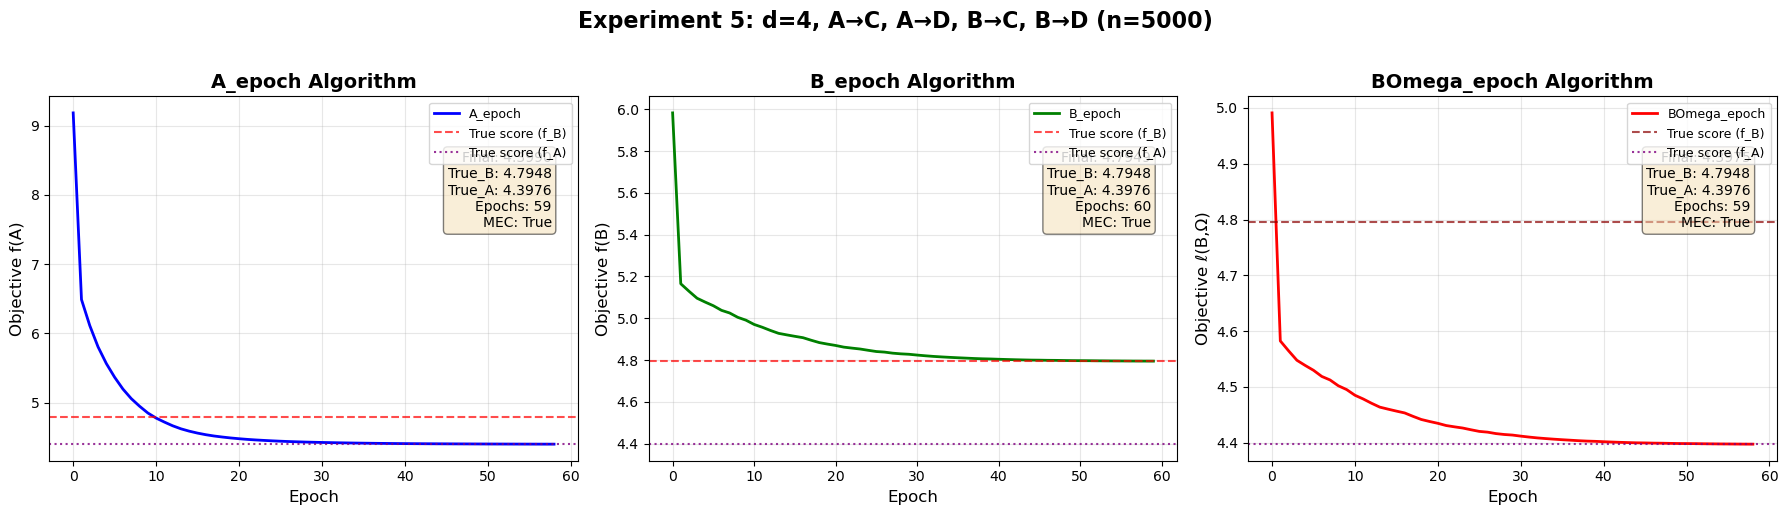

In [9]:
# Visualization: Objective function evolution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: A_epoch (scaled)
axes[0].plot(history_l0_scaled, linewidth=2, color='blue', label='A_epoch')
axes[0].axhline(y=score_true, color='red', linestyle='--', linewidth=1.5, label='True score (f_B)', alpha=0.7)
axes[0].axhline(y=score_true_A, color='purple', linestyle=':', linewidth=1.5, label='True score (f_A)', alpha=0.8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Objective f(A)', fontsize=12)
axes[0].set_title('A_epoch Algorithm', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, loc='upper right')
axes[0].text(0.95, 0.85, f'Final: {score_l0_scaled:.4f}\nTrue_B: {score_true:.4f}\nTrue_A: {score_true_A:.4f}\nEpochs: {len(history_l0)}\nMEC: {is_mec_l0}',
             transform=axes[0].transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: B_epoch
axes[1].plot(history_B, linewidth=2, color='green', label='B_epoch')
axes[1].axhline(y=score_true, color='red', linestyle='--', linewidth=1.5, label='True score (f_B)', alpha=0.7)
axes[1].axhline(y=score_true_A, color='purple', linestyle=':', linewidth=1.5, label='True score (f_A)', alpha=0.8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Objective f(B)', fontsize=12)
axes[1].set_title('B_epoch Algorithm', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9, loc='upper right')
axes[1].text(0.95, 0.85, f'Final: {score_B:.4f}\nTrue_B: {score_true:.4f}\nTrue_A: {score_true_A:.4f}\nEpochs: {len(history_B)}\nMEC: {is_mec_B}',
             transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 3: BOmega_epoch
axes[2].plot(history_BOmega, linewidth=2, color='red', label='BOmega_epoch')
axes[2].axhline(y=score_true, color='darkred', linestyle='--', linewidth=1.5, label='True score (f_B)', alpha=0.7)
axes[2].axhline(y=score_true_A, color='purple', linestyle=':', linewidth=1.5, label='True score (f_A)', alpha=0.8)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Objective ℓ(B,Ω)', fontsize=12)
axes[2].set_title('BOmega_epoch Algorithm', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=9, loc='upper right')
axes[2].text(0.95, 0.85, f'Final: {score_BOmega:.4f}\nTrue_B: {score_true:.4f}\nTrue_A: {score_true_A:.4f}\nEpochs: {len(history_BOmega)}\nMEC: {is_mec_BOmega}',
             transform=axes[2].transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Experiment 5: {experiment["name"]} (n={n_samples})', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

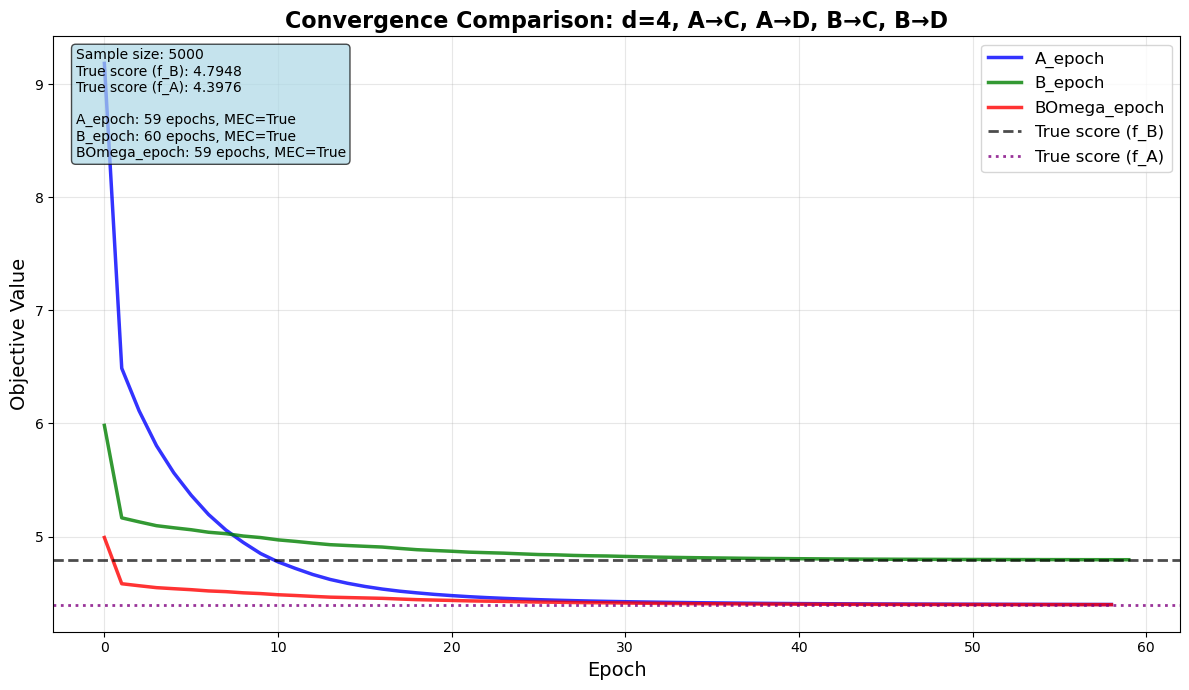

In [10]:
# Combined visualization: All three algorithms on one plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot algorithms with scaled history for A_epoch
ax.plot(history_l0_scaled, linewidth=2.5, label='A_epoch', color='blue', alpha=0.8)
ax.plot(history_B, linewidth=2.5, label='B_epoch', color='green', alpha=0.8)
ax.plot(history_BOmega, linewidth=2.5, label='BOmega_epoch', color='red', alpha=0.8)
ax.axhline(y=score_true, color='black', linestyle='--', linewidth=2, label='True score (f_B)', alpha=0.7)
ax.axhline(y=score_true_A, color='purple', linestyle=':', linewidth=2, label='True score (f_A)', alpha=0.8)

ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('Objective Value', fontsize=14)
ax.set_title(f'Convergence Comparison: {experiment["name"]}', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)

# Add convergence info
info_text = f'Sample size: {n_samples}\n'
info_text += f'True score (f_B): {score_true:.4f}\n'
info_text += f'True score (f_A): {score_true_A:.4f}\n\n'
info_text += f'A_epoch: {len(history_l0)} epochs, MEC={is_mec_l0}\n'
info_text += f'B_epoch: {len(history_B)} epochs, MEC={is_mec_B}\n'
info_text += f'BOmega_epoch: {len(history_BOmega)} epochs, MEC={is_mec_BOmega}'

ax.text(0.02, 0.98, info_text,
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

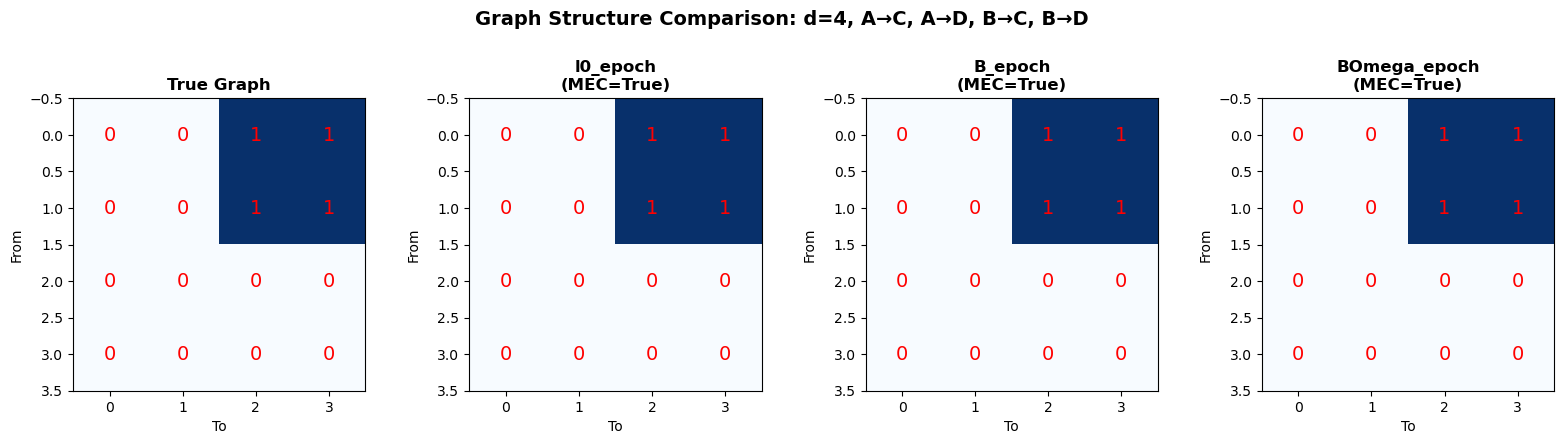

In [11]:
# Visualization: Adjacency matrices comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# True adjacency
G_true = (np.abs(B_true) > 0.01).astype(int)
axes[0].imshow(G_true, cmap='Blues', interpolation='nearest')
axes[0].set_title('True Graph', fontsize=12, fontweight='bold')
axes[0].set_xlabel('To')
axes[0].set_ylabel('From')
for i in range(d):
    for j in range(d):
        axes[0].text(j, i, str(G_true[i, j]), ha='center', va='center', color='red', fontsize=14)

# l0_epoch result
axes[1].imshow(G_l0, cmap='Blues', interpolation='nearest')
axes[1].set_title(f'l0_epoch\n(MEC={is_mec_l0})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('To')
axes[1].set_ylabel('From')
for i in range(d):
    for j in range(d):
        axes[1].text(j, i, str(G_l0[i, j]), ha='center', va='center', color='red', fontsize=14)

# B_epoch result
axes[2].imshow(G_B, cmap='Blues', interpolation='nearest')
axes[2].set_title(f'B_epoch\n(MEC={is_mec_B})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('To')
axes[2].set_ylabel('From')
for i in range(d):
    for j in range(d):
        axes[2].text(j, i, str(G_B[i, j]), ha='center', va='center', color='red', fontsize=14)

# BOmega_epoch result
axes[3].imshow(G_BOmega, cmap='Blues', interpolation='nearest')
axes[3].set_title(f'BOmega_epoch\n(MEC={is_mec_BOmega})', fontsize=12, fontweight='bold')
axes[3].set_xlabel('To')
axes[3].set_ylabel('From')
for i in range(d):
    for j in range(d):
        axes[3].text(j, i, str(G_BOmega[i, j]), ha='center', va='center', color='red', fontsize=14)

plt.suptitle(f'Graph Structure Comparison: {experiment["name"]}', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()